In [2]:
import torch
import torch.nn as nn

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

batch = torch.stack((inputs, inputs), dim=0)
print("Batch Shape:", batch.shape)
print("Batch Tensor:\n", batch)

Batch Shape: torch.Size([2, 6, 3])
Batch Tensor:
 tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]]])


In [11]:
class CausalAttention(nn.Module):
    def __init__(self, d_in,d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length),diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        values = self.W_value(x)
        queries = self.W_query(x)

        attn_scores = queries @ keys.transpose(1, 2)
        attn_scores = attn_scores.masked_fill(           # ✅ non in-place
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ values
        return context_vec


In [13]:
torch.manual_seed(123)  # For reproducibility
context_length = batch.shape[1]
d_out = 2
ca = CausalAttention(d_in = inputs.shape[1], d_out=d_out, context_length=context_length, dropout=0.5)
context_vectors = ca(batch)
print("Context Vectors Shape:", context_vectors.shape)
print("Context Vectors:\n", context_vectors)


Context Vectors Shape: torch.Size([2, 6, 2])
Context Vectors:
 tensor([[[-0.9038,  0.4432],
         [-0.4368,  0.2142],
         [-0.4849, -0.1341],
         [-0.5834,  0.0081],
         [-0.6219, -0.0526],
         [-0.1417, -0.0505]],

        [[ 0.0000,  0.0000],
         [-1.1749,  0.0116],
         [-0.7733,  0.0073],
         [-0.9140, -0.2769],
         [-0.7679, -0.0735],
         [-0.6749, -0.0984]]], grad_fn=<UnsafeViewBackward0>)


## Create a simple MultiHeadAttention Stack 2 CausalAttention


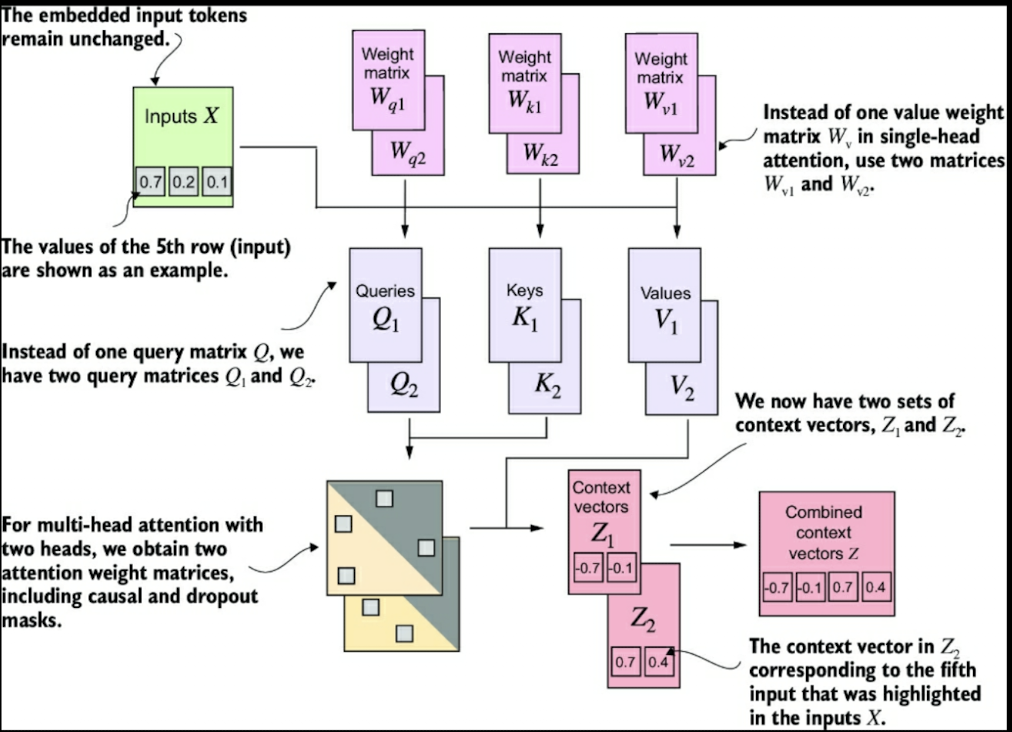

In [20]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList([
            CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)
            for _ in range(num_heads)
        ])

    def forward(self, x):
        head_outputs = [head(x) for head in self.heads]
        return torch.cat(head_outputs, dim=-1)
    

In [22]:
torch.manual_seed(123)  # For reproducibility
context_length = batch.shape[1]
d_in, d_out = inputs.shape[1], 2

mha = MultiHeadAttentionWrapper(d_in=d_in, d_out=d_out, context_length=context_length, dropout=0.5, num_heads=2)
context_vectors_mha = mha(batch)
print("Multi-Head Context Vectors Shape:", context_vectors_mha.shape)
print("Multi-Head Context Vectors:\n", context_vectors_mha)

Multi-Head Context Vectors Shape: torch.Size([2, 6, 4])
Multi-Head Context Vectors:
 tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000],
         [-0.7381, -0.2026,  0.0000,  0.0000],
         [-0.9717, -0.2678,  0.9703,  0.7117],
         [-0.2210,  0.1084,  0.3492,  0.2569],
         [-0.4833, -0.1435,  0.4143,  0.3235],
         [-0.9130, -0.2881,  0.8947,  0.5938]],

        [[ 0.0000,  0.0000,  0.9544,  0.2127],
         [ 0.0000,  0.0000,  1.1781,  0.6513],
         [-0.7751,  0.0077,  0.4856,  0.3552],
         [-0.5504, -0.1770,  0.8795,  0.6697],
         [-0.8117, -0.1150,  0.4682,  0.3227],
         [-0.4257, -0.1539,  0.6311,  0.4446]]], grad_fn=<CatBackward0>)
